<a href="https://colab.research.google.com/github/chethanks506-dot/NLP-Workbench/blob/main/AAT2_NLP_SENTI_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (20, 11)

Columns:
0 : Timestamp
1 : 1. How accurately does the faculty adhere to class start times and session duration? 
2 : 2. How systematically is the course syllabus being completed according to the academic plan?  
3 : 3. How effectively does the faculty explain core theoretical concepts in Natural Language Processing?  
4 : 4. How well does the faculty connect theoretical topics with practical, real-world NLP applications?  
5 : 5. How well does the faculty address questions and clear student doubts during or after lectures?  
6 : 6. How engaging and interactive are the faculty's teaching methods during lectures?  
7 : 7. How would you rate the faculty's attitude and rapport with students?  
8 : 8. How effectively does the faculty maintain classroom order and a productive learning environment?  
9 : 9. How appropriate is the faculty's speed of teaching and explanation?  
10 : 10. What is your overall experience with this faculty's instruction for this course?  



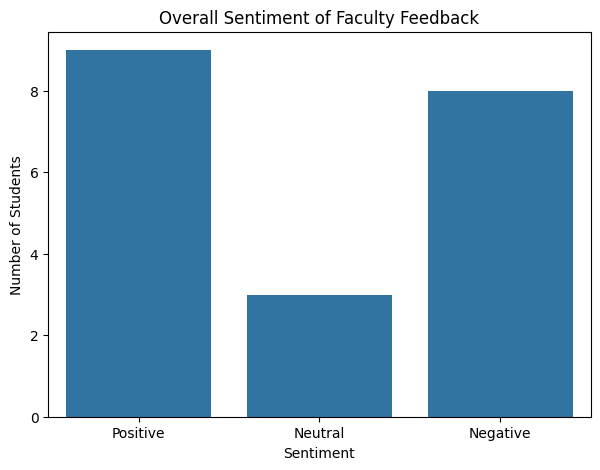


================ QUESTION-WISE SENTIMENT ================



,Question,Positive,Neutral,Negative
0,Q1,12,1,7
1,Q2,0,20,0
2,Q3,0,18,2
3,Q4,9,6,5
4,Q5,11,3,6
5,Q6,6,6,8
6,Q7,6,5,9
7,Q8,6,7,7
8,Q9,11,5,4
9,Q10,10,4,6


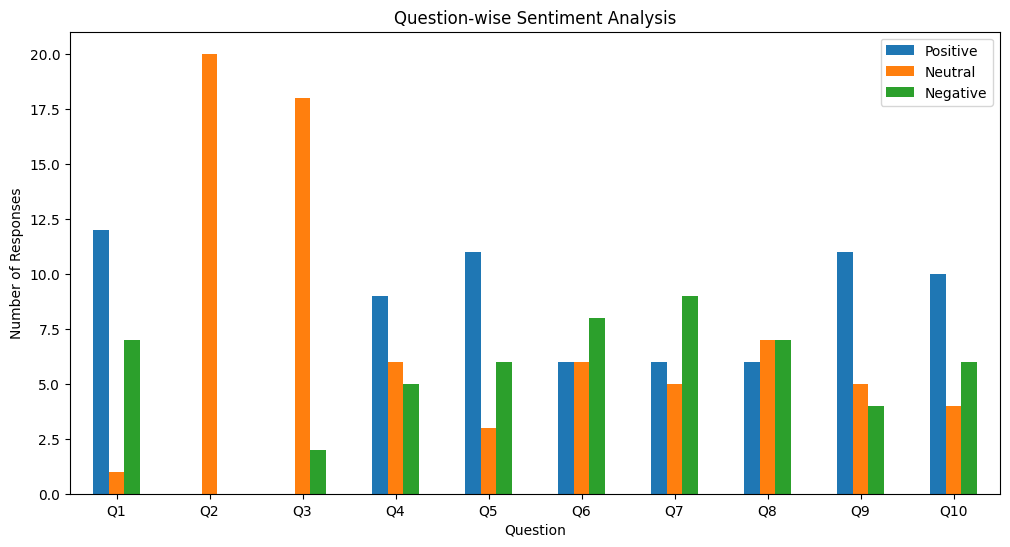


================ SENTIMENT SCORE BY QUESTION ================



,Question,Positive,Neutral,Negative,Sentiment Score
8,Q9,11,5,4,7
0,Q1,12,1,7,5
4,Q5,11,3,6,5
9,Q10,10,4,6,4
3,Q4,9,6,5,4
1,Q2,0,20,0,0
7,Q8,6,7,7,-1
2,Q3,0,18,2,-2
5,Q6,6,6,8,-2
6,Q7,6,5,9,-3



SENTIMENT ANALYSIS COMPLETED SUCCESSFULLY

Files created:
1. NLP_Faculty_Feedback_Sentiment_Results.csv
2. Question_Wise_Sentiment_Summary.csv


In [2]:
# ============================================================
# NLP AAT - FACULTY FEEDBACK SENTIMENT ANALYSIS
# ============================================================

!pip -q install pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

file = "AAT2_NLP_DATA - Form responses 1.csv"

df = pd.read_csv(file)

print("Dataset Shape:", df.shape)
print("\nColumns:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

# ------------------------------------------------------------
# 2. REMOVE UNNECESSARY TIMESTAMP
# ------------------------------------------------------------

df = df.drop(columns=["Timestamp"])

# ------------------------------------------------------------
# 3. TEXT CLEANING
# ------------------------------------------------------------

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ------------------------------------------------------------
# 4. SENTIMENT CLASSIFICATION
# ------------------------------------------------------------

def classify_sentiment(text):

    text = clean_text(text)

    # -------- STRONGLY NEGATIVE --------
    negative_phrases = [
        "dissatisfied",
        "unsupportive",
        "disrespectful",
        "discourages questions",
        "hard to approach",
        "passive boring",
        "non interactive",
        "limited practical application",
        "mostly theoretical",
        "hard to follow",
        "needs simpler explanations",
        "poor",
        "very poor",
        "needs significant improvement",
        "too fast or too slow"
    ]

    # -------- STRONGLY POSITIVE --------
    positive_phrases = [
        "highly satisfied",
        "outstanding teaching quality",
        "excellent",
        "very encouraging",
        "accessible",
        "clear answers",
        "highly engaging",
        "actively involved",
        "very polite",
        "respectful",
        "encouraging",
        "ideal",
        "highly focused",
        "perfect pace",
        "easy to keep up",
        "excellent practical examples",
        "industry context provided",
        "good",
        "generally helpful"
    ]

    # -------- NEUTRAL --------
    neutral_phrases = [
        "neutral",
        "needs improvement in specific areas",
        "mostly on schedule with minor pacing issues",
        "occasionally complex explanations",
        "reasonable order with minimal distractions",
        "slightly fast slow at times"
    ]

    # Check negative first
    for phrase in negative_phrases:
        if phrase in text:
            return "Negative"

    # Check positive
    for phrase in positive_phrases:
        if phrase in text:
            return "Positive"

    # Check neutral
    for phrase in neutral_phrases:
        if phrase in text:
            return "Neutral"

    # Fallback
    return "Neutral"


# ------------------------------------------------------------
# 5. APPLY SENTIMENT ANALYSIS TO ALL QUESTIONS
# ------------------------------------------------------------

question_columns = df.columns

for column in question_columns:

    sentiment_column = column.strip() + " - Sentiment"

    df[sentiment_column] = df[column].apply(classify_sentiment)


# ------------------------------------------------------------
# 6. OVERALL SENTIMENT
# ------------------------------------------------------------

sentiment_columns = [
    col for col in df.columns
    if col.endswith("- Sentiment")
]

sentiment_number = {
    "Positive": 1,
    "Neutral": 0,
    "Negative": -1
}

# Calculate average sentiment for every student
def calculate_overall(row):

    values = [
        sentiment_number[row[col]]
        for col in sentiment_columns
    ]

    average = sum(values) / len(values)

    if average >= 0.30:
        return "Positive"

    elif average <= -0.30:
        return "Negative"

    else:
        return "Neutral"


df["Overall Sentiment"] = df.apply(
    calculate_overall,
    axis=1
)


# ------------------------------------------------------------
# 7. DISPLAY SENTIMENT RESULTS
# ------------------------------------------------------------

print("\n================ SENTIMENT RESULTS ================\n")

for i in range(len(df)):

    print("Student", i + 1, ":", df.iloc[i]["Overall Sentiment"])


# ------------------------------------------------------------
# 8. OVERALL SENTIMENT DISTRIBUTION
# ------------------------------------------------------------

overall_counts = df["Overall Sentiment"].value_counts()

print("\n================ OVERALL DISTRIBUTION ================\n")

print(overall_counts)

# ------------------------------------------------------------
# 9. PERCENTAGE DISTRIBUTION
# ------------------------------------------------------------

overall_percentage = (
    df["Overall Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n================ PERCENTAGE ================\n")

print(overall_percentage)


# ------------------------------------------------------------
# 10. PLOT OVERALL SENTIMENT
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Overall Sentiment",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Overall Sentiment of Faculty Feedback")
plt.xlabel("Sentiment")
plt.ylabel("Number of Students")

plt.show()


# ------------------------------------------------------------
# 11. SENTIMENT ANALYSIS FOR EACH QUESTION
# ------------------------------------------------------------

question_sentiments = []

for i, column in enumerate(question_columns):

    sentiment_column = column.strip() + " - Sentiment"

    counts = df[sentiment_column].value_counts()

    question_sentiments.append({
        "Question": f"Q{i+1}",
        "Positive": counts.get("Positive", 0),
        "Neutral": counts.get("Neutral", 0),
        "Negative": counts.get("Negative", 0)
    })


question_summary = pd.DataFrame(question_sentiments)

print("\n================ QUESTION-WISE SENTIMENT ================\n")

display(question_summary)


# ------------------------------------------------------------
# 12. QUESTION-WISE SENTIMENT GRAPH
# ------------------------------------------------------------

question_summary.set_index("Question")[
    ["Positive", "Neutral", "Negative"]
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Question-wise Sentiment Analysis")
plt.xlabel("Question")
plt.ylabel("Number of Responses")
plt.xticks(rotation=0)

plt.show()


# ------------------------------------------------------------
# 13. FIND BEST AND WORST AREAS
# ------------------------------------------------------------

question_summary["Sentiment Score"] = (
    question_summary["Positive"]
    - question_summary["Negative"]
)

print("\n================ SENTIMENT SCORE BY QUESTION ================\n")

display(
    question_summary.sort_values(
        "Sentiment Score",
        ascending=False
    )
)


# ------------------------------------------------------------
# 14. SAVE RESULTS
# ------------------------------------------------------------

df.to_csv(
    "NLP_Faculty_Feedback_Sentiment_Results.csv",
    index=False
)

question_summary.to_csv(
    "Question_Wise_Sentiment_Summary.csv",
    index=False
)

print("\n================================================")
print("SENTIMENT ANALYSIS COMPLETED SUCCESSFULLY")
print("================================================")

print("\nFiles created:")
print("1. NLP_Faculty_Feedback_Sentiment_Results.csv")
print("2. Question_Wise_Sentiment_Summary.csv")